# Healthcare Access/ Notebook 3: Machine Learning & SHAP Explainability

Predict which Dissemination Areas fall in the worst MAG quartile (Q4 = most disadvantaged) using CIMD deprivation dimensions & urban morphology features. Then use SHAP to decompose which features drive the prediction, answering the research question: *which dimensions of deprivation most strongly predict modal access inequality?*

**Model:** XGBoost binary classifier (Q4 vs Q1–Q3)  
**Explainability:** SHAP beeswarm, bar, dependence, and interaction plots  
**Inputs:** `calgary_DA_MAG_CIMD.csv` from Notebook 1

## 0. Imports & Paths

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ML
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
import shap

print('All imports OK')

# Paths
BASE_DIR      = r'E:\phD work\Clgary project\MGAP'  # <-- same as NB1 & NB2
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
OUTPUTS_DIR   = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

All imports OK


In [ ]:

# Uncomment and run once if imports above failed, then restart kernel
#import subprocess, sys
#subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', 'shap', 'scikit-learn'])

0

## 1. Load & Prepare Data

In [2]:

df = pd.read_csv(
    os.path.join(PROCESSED_DIR, 'calgary_DA_MAG_CIMD.csv'),
    dtype={'DAUID': str}
)
print(f'Loaded: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Loaded: (1898, 16)
Columns: ['DAUID', 'MAG_mean', 'MAG_std', 'hf_transit_mean', 'hf_walk_mean', 'n_blocks', 'CSDNAME', 'CMANAME', 'Residential instability Scores', 'Economic dependency Scores', 'Situational vulnerability Scores', 'Ethno-cultural composition Scores', 'Residential instability Quintiles', 'Economic dependency Quintiles', 'Situational vulnerability Quintiles', 'Ethno-cultural composition Quintiles']


In [3]:
# Define feature columns
CIMD_SCORE_COLS = [
    'Residential instability Scores',
    'Economic dependency Scores',
    'Situational vulnerability Scores',
    'Ethno-cultural composition Scores',
]

# Urban morphology features already in table
MORPH_COLS = [
    'n_blocks',      # number of DBs in the DA (proxy for DA size/density)
    'MAG_std',       # intra-DA variability in MAG
    'hf_transit_mean',  # absolute transit access level
    'hf_walk_mean',     # absolute walking access level
]

# Check which morphology cols actually exist
MORPH_COLS = ['n_blocks', 'MAG_std']
MORPH_COLS = [c for c in MORPH_COLS if c in df.columns]

FEATURE_COLS = CIMD_SCORE_COLS + MORPH_COLS
print(f'Features after removing leaking variables: {FEATURE_COLS}')

Features after removing leaking variables: ['Residential instability Scores', 'Economic dependency Scores', 'Situational vulnerability Scores', 'Ethno-cultural composition Scores', 'n_blocks', 'MAG_std']


In [4]:
# Build target variable
# Binary: 1 = Q4 (most disadvantaged MAG), 0 = Q1-Q3
# Compute quartiles fresh here from MAG_mean

df_ml = df.dropna(subset=['MAG_mean'] + CIMD_SCORE_COLS).copy()

df_ml['MAG_quartile'] = pd.qcut(
    df_ml['MAG_mean'], q=4, labels=[1, 2, 3, 4]
).astype(int)

# Target: 1 = worst quartile (Q4 = most negative MAG = largest access gap)
df_ml['target'] = (df_ml['MAG_quartile'] == 4).astype(int)

print(f'Total DAs for ML : {len(df_ml):,}')
print(f'Class distribution:')
print(f'  Q4 (target=1) : {df_ml["target"].sum():,} ({100*df_ml["target"].mean():.1f}%)')
print(f'  Q1-Q3 (target=0): {(df_ml["target"]==0).sum():,} ({100*(df_ml["target"]==0).mean():.1f}%)')

Total DAs for ML : 1,778
Class distribution:
  Q4 (target=1) : 445 (25.0%)
  Q1-Q3 (target=0): 1,333 (75.0%)


In [5]:
# Prepare X and y
X = df_ml[FEATURE_COLS].copy()
y = df_ml['target'].copy()

# Short feature names for plots
FEATURE_NAMES_SHORT = {
    'Residential instability Scores'    : 'Residential Instability',
    'Economic dependency Scores'        : 'Economic Dependency',
    'Situational vulnerability Scores'  : 'Situational Vulnerability',
    'Ethno-cultural composition Scores' : 'Ethno-cultural Composition',
    'n_blocks'                          : 'Block Count (DA size)',
    'MAG_std'                           : 'Intra-DA MAG Variability',
    'hf_transit_mean'                   : 'Transit Access Level',
    'hf_walk_mean'                      : 'Walking Access Level',
}
X.columns = [FEATURE_NAMES_SHORT.get(c, c) for c in X.columns]
FEATURE_NAMES = X.columns.tolist()

print(f'X shape: {X.shape}')
print(f'Feature names: {FEATURE_NAMES}')
print(f'\nMissing values per feature:')
print(X.isna().sum())

X shape: (1778, 6)
Feature names: ['Residential Instability', 'Economic Dependency', 'Situational Vulnerability', 'Ethno-cultural Composition', 'Block Count (DA size)', 'Intra-DA MAG Variability']

Missing values per feature:
Residential Instability         0
Economic Dependency             0
Situational Vulnerability       0
Ethno-cultural Composition      0
Block Count (DA size)           0
Intra-DA MAG Variability      130
dtype: int64


## 2. Cross-Validated Model Training

Using 5-fold stratified cross-validation to get robust performance estimates rather than a single train/test split (dataset of about 1,800 rows.)

In [6]:
# XGBoost model definition
# scale_pos_weight handles class imbalance (75% negative, 25% positive)
neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
scale_pos = neg_count / pos_count

xgb_model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 42,
    verbosity         = 0
)

print(f'scale_pos_weight: {scale_pos:.2f}  (balances {neg_count} negatives vs {pos_count} positives)')

scale_pos_weight: 3.00  (balances 1333 negatives vs 445 positives)


In [7]:
# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    xgb_model, X, y, cv=cv,
    scoring=['roc_auc', 'f1', 'accuracy', 'precision', 'recall'],
    return_train_score=True
)

print('5-Fold Cross-Validation Results:')
print(f'{"Metric":<25} {"Mean":>8} {"Std":>8}')
print('-' * 45)
for metric in ['test_roc_auc', 'test_f1', 'test_accuracy', 'test_precision', 'test_recall']:
    vals = cv_results[metric]
    label = metric.replace('test_', '').replace('_', ' ').title()
    print(f'{label:<25} {vals.mean():>8.4f} {vals.std():>8.4f}')

print(f'\nTrain ROC-AUC (avg): {cv_results["train_roc_auc"].mean():.4f}  (gap to test = {cv_results["train_roc_auc"].mean() - cv_results["test_roc_auc"].mean():.4f})')

5-Fold Cross-Validation Results:
Metric                        Mean      Std
---------------------------------------------
Roc Auc                     0.8174   0.0193
F1                          0.5999   0.0233
Accuracy                    0.7863   0.0152
Precision                   0.5664   0.0324
Recall                      0.6404   0.0408

Train ROC-AUC (avg): 0.9881  (gap to test = 0.1707)


In [8]:
#Fit final model on all data for SHAP analysis
# fit on full dataset for SHAP: cross-val
xgb_model.fit(X, y)
print('Final model fitted on full dataset')
print(f'Features used: {len(FEATURE_NAMES)}')

Final model fitted on full dataset
Features used: 6


## 3. Model Evaluation: ROC Curve & Confusion Matrix

In [9]:
# Get predictions from cross-val for honest evaluation plots 
from sklearn.model_selection import cross_val_predict

y_prob = cross_val_predict(xgb_model, X, y, cv=cv, method='predict_proba')[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print('Classification Report (cross-validated predictions):')
print(classification_report(y, y_pred, target_names=['Q1-Q3 (not worst)', 'Q4 (worst MAG)']))

auc = roc_auc_score(y, y_prob)
print(f'ROC-AUC: {auc:.4f}')

Classification Report (cross-validated predictions):
                   precision    recall  f1-score   support

Q1-Q3 (not worst)       0.87      0.83      0.85      1333
   Q4 (worst MAG)       0.56      0.64      0.60       445

         accuracy                           0.79      1778
        macro avg       0.72      0.74      0.73      1778
     weighted avg       0.80      0.79      0.79      1778

ROC-AUC: 0.8166


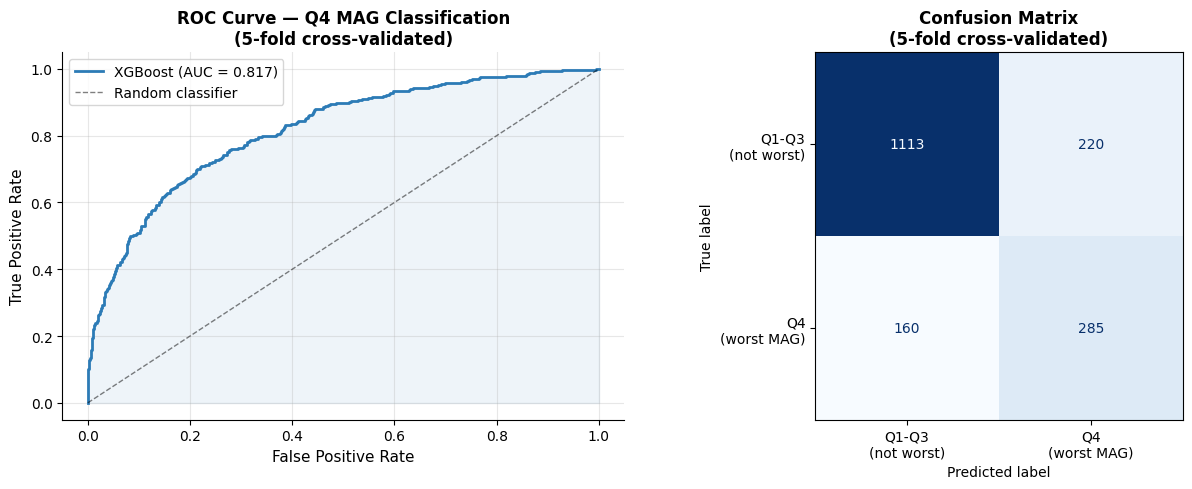

Saved: E:\phD work\Clgary project\MGAP\outputs\Fig7_ROC_confusion.png


In [10]:
# Figure 7: ROC curve & Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: ROC curve
fpr, tpr, _ = roc_curve(y, y_prob)
axes[0].plot(fpr, tpr, color='#2c7bb6', linewidth=2,
             label=f'XGBoost (AUC = {auc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#2c7bb6')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve — Q4 MAG Classification\n(5-fold cross-validated)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Right: Confusion matrix
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Q1-Q3\n(not worst)', 'Q4\n(worst MAG)']
)
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix\n(5-fold cross-validated)',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'Fig7_ROC_confusion.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out}')

## 4. SHAP Explainability

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for each prediction. Unlike feature importance from the model itself, SHAP values are theoretically grounded (based on cooperative game theory) and show both the direction and magnitude of each feature's effect.

In [13]:
# Compute SHAP values
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer(X)

# shap_values.values shape: (n_samples, n_features)
print(f'SHAP values shape: {shap_values.values.shape}')

SHAP values shape: (1778, 6)


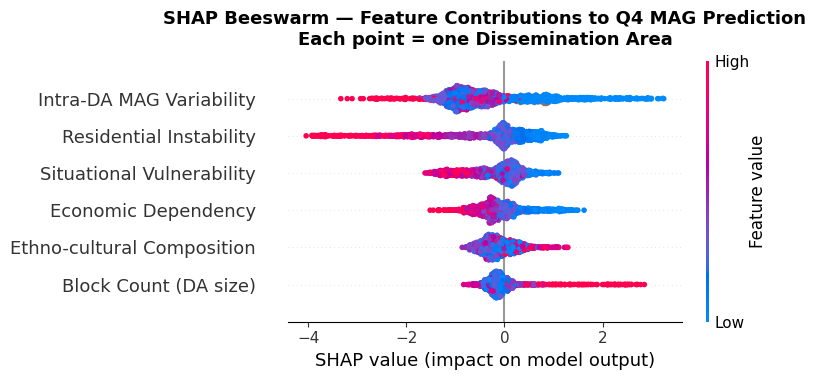

Saved: E:\phD work\Clgary project\MGAP\outputs\Fig8_SHAP_beeswarm.png


In [14]:
# Figure 8: SHAP Beeswarm plot
# The beeswarm is the single most informative SHAP plot:
# Each dot = one DA
# x-axis = SHAP value (positive = pushes toward Q4 prediction)
# colour = feature value (red = high, blue = low)

fig, ax = plt.subplots(figsize=(11, 6))
shap.plots.beeswarm(shap_values, max_display=len(FEATURE_NAMES),
                    show=False)
plt.title('SHAP Beeswarm — Feature Contributions to Q4 MAG Prediction\n'
          'Each point = one Dissemination Area',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'Fig8_SHAP_beeswarm.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out}')

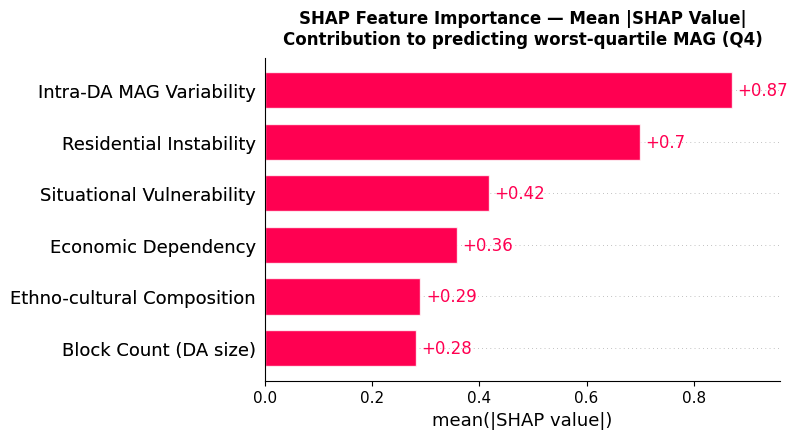

Saved: E:\phD work\Clgary project\MGAP\outputs\Fig9_SHAP_bar.png


In [15]:
# Figure 9: SHAP Mean Absolute Bar plot
# Shows global feature importance ranked by mean SHAP value

fig, ax = plt.subplots(figsize=(9, 5))
shap.plots.bar(shap_values, max_display=len(FEATURE_NAMES), show=False)
plt.title('SHAP Feature Importance — Mean |SHAP Value|\n'
          'Contribution to predicting worst-quartile MAG (Q4)',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'Fig9_SHAP_bar.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out}')

Top 2 features by SHAP importance: ['Intra-DA MAG Variability', 'Residential Instability']


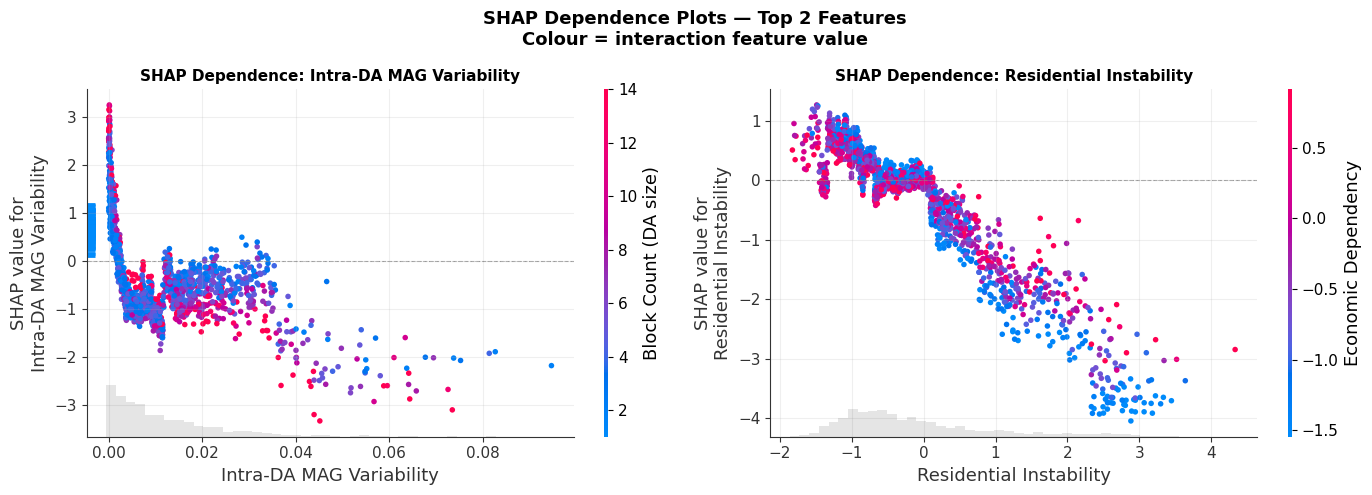

Saved: E:\phD work\Clgary project\MGAP\outputs\Fig10_SHAP_dependence.png


In [16]:
# Figure 10: SHAP Dependence plots: top 2 CIMD features
# Dependence plot shows how SHAP value changes as feature value changes
# The colour shows the interaction with the most correlated other feature

# Get top 2 features by mean absolute SHAP value
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top2_idx = np.argsort(mean_abs_shap)[::-1][:2]
top2_features = [FEATURE_NAMES[i] for i in top2_idx]
print(f'Top 2 features by SHAP importance: {top2_features}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, feat in enumerate(top2_features):
    shap.plots.scatter(
        shap_values[:, feat],
        color=shap_values,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'SHAP Dependence: {feat}',
                      fontsize=11, fontweight='bold')
    axes[i].axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
    axes[i].grid(True, alpha=0.2)

plt.suptitle('SHAP Dependence Plots — Top 2 Features\n'
             'Colour = interaction feature value',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'Fig10_SHAP_dependence.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out}')

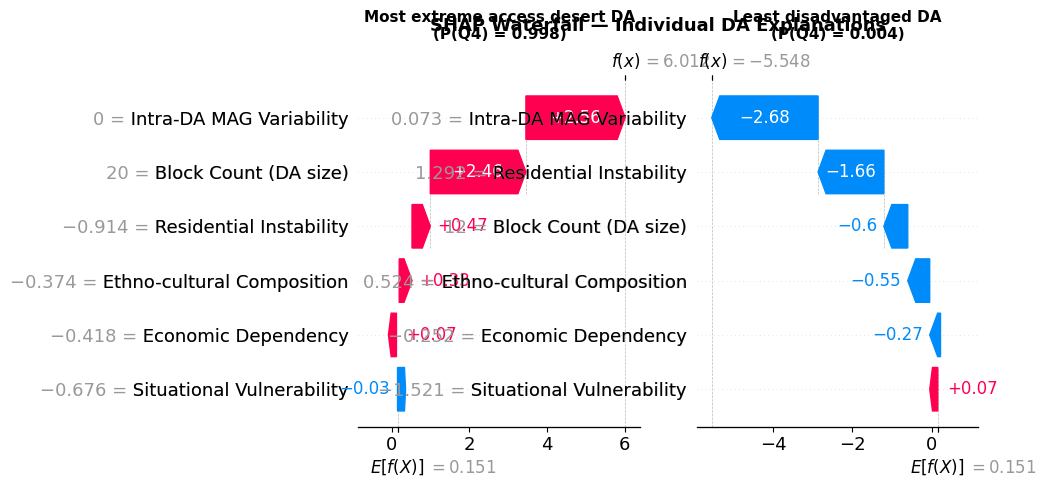

Saved: E:\phD work\Clgary project\MGAP\outputs\Fig11_SHAP_waterfall.png


In [17]:
# Figure 11: SHAP Waterfall: single DA example
# copied to show how the model builds its prediction for the single most extreme Q4 DA and single most extreme Q1 DA

# Find the DA with highest predicted Q4 probability (most extreme access desert)
y_prob_full = xgb_model.predict_proba(X)[:, 1]
worst_idx = np.argmax(y_prob_full)
best_idx  = np.argmin(y_prob_full)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, idx, label in [
    (axes[0], worst_idx, f'Most extreme access desert DA\n(P(Q4) = {y_prob_full[worst_idx]:.3f})'),
    (axes[1], best_idx,  f'Least disadvantaged DA\n(P(Q4) = {y_prob_full[best_idx]:.3f})')
]:
    plt.sca(ax)
    shap.plots.waterfall(shap_values[idx], max_display=len(FEATURE_NAMES), show=False)
    plt.title(label, fontsize=11, fontweight='bold', pad=8)

plt.suptitle('SHAP Waterfall — Individual DA Explanations',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'Fig11_SHAP_waterfall.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out}')

## 5. SHAP Interaction Analysis

Tests whether specific deprivation dimension combinations produce non-linear MAG amplification (not possible to test by linear models)

In [18]:
# Compute SHAP interaction values 
shap_interaction = explainer.shap_interaction_values(X)
print(f'Interaction values shape: {shap_interaction.shape}')
# Shape: (n_samples, n_features, n_features)
# Diagonal = main effects, off-diagonal = pairwise interactions

Interaction values shape: (1778, 6, 6)


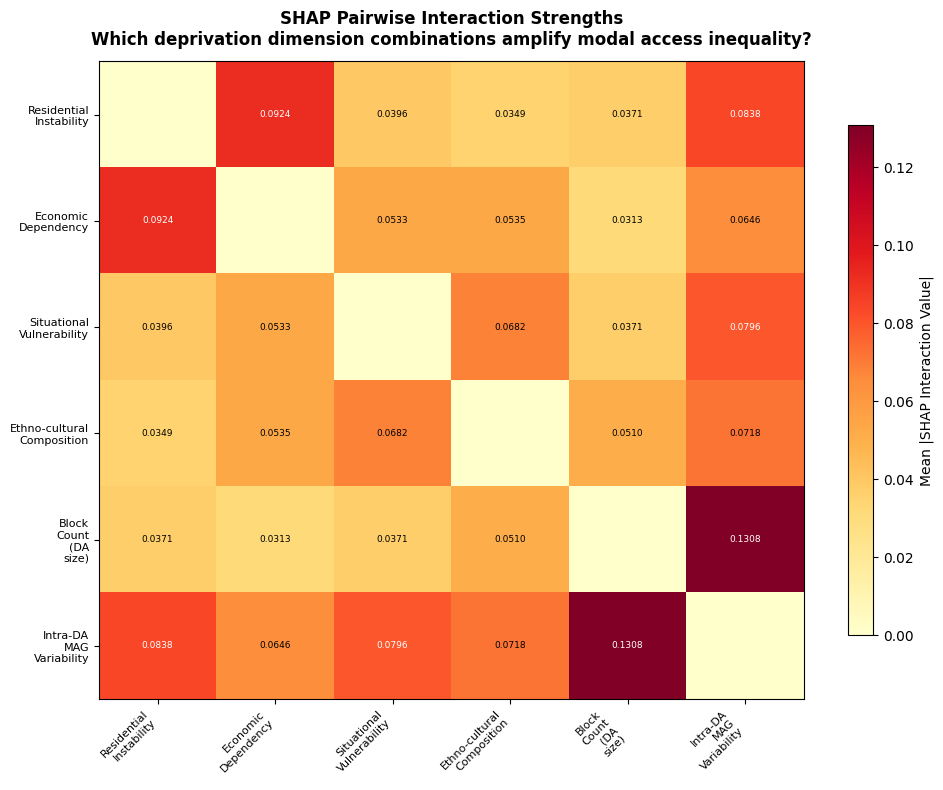

Saved: E:\phD work\Clgary project\MGAP\outputs\Fig12_SHAP_interaction_heatmap.png

Top 5 strongest pairwise interactions:
                 Feature A                Feature B  Interaction Strength
     Block Count (DA size) Intra-DA MAG Variability              0.130785
   Residential Instability      Economic Dependency              0.092432
   Residential Instability Intra-DA MAG Variability              0.083837
 Situational Vulnerability Intra-DA MAG Variability              0.079585
Ethno-cultural Composition Intra-DA MAG Variability              0.071807


In [19]:
#  Figure 12: Interaction strength heatmap
# Mean absolute interaction value between each pair of features
n_feat = len(FEATURE_NAMES)
interaction_matrix = np.abs(shap_interaction).mean(axis=0)

# Zero out diagonal (main effects) to focus on interactions
interaction_off_diag = interaction_matrix.copy()
np.fill_diagonal(interaction_off_diag, 0)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(interaction_off_diag, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Mean |SHAP Interaction Value|')

short = [n.replace(' ', '\n') for n in FEATURE_NAMES]
ax.set_xticks(range(n_feat))
ax.set_yticks(range(n_feat))
ax.set_xticklabels(short, fontsize=8, rotation=45, ha='right')
ax.set_yticklabels(short, fontsize=8)

# Annotate cells
for i in range(n_feat):
    for j in range(n_feat):
        if i != j:
            ax.text(j, i, f'{interaction_off_diag[i,j]:.4f}',
                   ha='center', va='center', fontsize=6.5,
                   color='black' if interaction_off_diag[i,j] < interaction_off_diag.max()*0.6 else 'white')

ax.set_title('SHAP Pairwise Interaction Strengths\n'
             'Which deprivation dimension combinations amplify modal access inequality?',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'Fig12_SHAP_interaction_heatmap.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out}')

# Print top 5 strongest interactions
print('\nTop 5 strongest pairwise interactions:')
pairs = []
for i in range(n_feat):
    for j in range(i+1, n_feat):
        pairs.append((FEATURE_NAMES[i], FEATURE_NAMES[j], interaction_off_diag[i,j]))
pairs_df = pd.DataFrame(pairs, columns=['Feature A','Feature B','Interaction Strength'])
print(pairs_df.sort_values('Interaction Strength', ascending=False).head(5).to_string(index=False))

## 6. CIMD-Only Model: Isolating Deprivation Effects

We refit using only the 4 CIMD dimensions (no morphology features) to get clean deprivation-specific SHAP values.

In [25]:
# CIMD-only feature matrix 
CIMD_SHORT = [
    'Residential Instability',
    'Economic Dependency',
    'Situational Vulnerability',
    'Ethno-cultural Composition'
]

X_cimd = df_ml[CIMD_SCORE_COLS].copy()
X_cimd.columns = CIMD_SHORT

# Cross-validate CIMD-only model
xgb_cimd = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, verbosity=0
)

cv_cimd = cross_validate(
    xgb_cimd, X_cimd, y, cv=cv,
    scoring=['roc_auc', 'f1'],
    return_train_score=False
)

print('CIMD-only model (4 deprivation features):')
print(f'  ROC-AUC: {cv_cimd["test_roc_auc"].mean():.4f} ± {cv_cimd["test_roc_auc"].std():.4f}')
print(f'  F1     : {cv_cimd["test_f1"].mean():.4f} ± {cv_cimd["test_f1"].std():.4f}')
print()
print('Full model (CIMD + morphology):')
print(f'  ROC-AUC: {cv_results["test_roc_auc"].mean():.4f} ± {cv_results["test_roc_auc"].std():.4f}')
print(f'  F1     : {cv_results["test_f1"].mean():.4f} ± {cv_results["test_f1"].std():.4f}')
print()
print('AUC difference shows how much morphology adds beyond deprivation alone')

CIMD-only model (4 deprivation features):
  ROC-AUC: 0.7252 ± 0.0324
  F1     : 0.5040 ± 0.0420

Full model (CIMD + morphology):
  ROC-AUC: 0.8174 ± 0.0193
  F1     : 0.5999 ± 0.0233

AUC difference shows how much morphology adds beyond deprivation alone


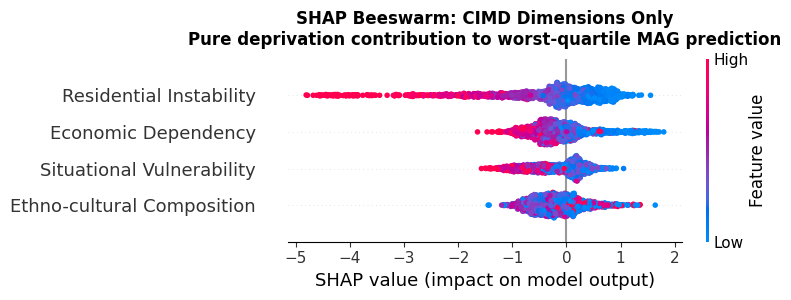

Saved: E:\phD work\Clgary project\MGAP\outputs\Fig13_SHAP_CIMD_only_beeswarm.png


In [27]:
# SHAP for CIMD-only model
xgb_cimd.fit(X_cimd, y)
explainer_cimd  = shap.TreeExplainer(xgb_cimd)
shap_cimd       = explainer_cimd(X_cimd)

# Figure 13: CIMD-only SHAP beeswarm
fig, ax = plt.subplots(figsize=(10, 5))
shap.plots.beeswarm(shap_cimd, max_display=4, show=False)
plt.title('SHAP Beeswarm: CIMD Dimensions Only\n'
          'Pure deprivation contribution to worst-quartile MAG prediction',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'Fig13_SHAP_CIMD_only_beeswarm.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out}')

## 7. Summary

In [30]:

print('NOTEBOOK 3 SUMMARY:  ML & SHAP FINDINGS')

print(f"""
DATASET
  DAs used for ML            : {len(df_ml):,}
  Features                   : {len(FEATURE_NAMES)}
  Target (Q4 share)          : {100*y.mean():.1f}%

MODEL PERFORMANCE (5-fold cross-validated)
  ROC-AUC (full model)       : {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}
  F1 Score                   : {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}
  Accuracy                   : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}

  ROC-AUC (CIMD-only model)  : {cv_cimd['test_roc_auc'].mean():.4f} ± {cv_cimd['test_roc_auc'].std():.4f}
  to Morphology adds          : {cv_results['test_roc_auc'].mean() - cv_cimd['test_roc_auc'].mean():.4f} AUC points

SHAP FEATURE RANKING (mean absolute SHAP value)
""")

shap_importance = pd.DataFrame({
    'Feature'           : FEATURE_NAMES,
    'Mean |SHAP|'       : np.abs(shap_values.values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)
print(shap_importance.to_string(index=False))

print('\nTOP PAIRWISE INTERACTION:')
print(pairs_df.sort_values('Interaction Strength', ascending=False).head(3).to_string(index=False))

# Save
shap_importance.to_csv(
    os.path.join(OUTPUTS_DIR, 'NB3_shap_importance.csv'), index=False
)
print(f'\nSaved: NB3_shap_importance.csv')
print('\nHealthcareAccess Analysis Complete')

NOTEBOOK 3 SUMMARY:  ML & SHAP FINDINGS

DATASET
  DAs used for ML            : 1,778
  Features                   : 6
  Target (Q4 share)          : 25.0%

MODEL PERFORMANCE (5-fold cross-validated)
  ROC-AUC (full model)       : 0.8174 ± 0.0193
  F1 Score                   : 0.5999 ± 0.0233
  Accuracy                   : 0.7863 ± 0.0152

  ROC-AUC (CIMD-only model)  : 0.7252 ± 0.0324
  to Morphology adds          : 0.0922 AUC points

SHAP FEATURE RANKING (mean absolute SHAP value)

                   Feature  Mean |SHAP|
  Intra-DA MAG Variability     0.871926
   Residential Instability     0.699749
 Situational Vulnerability     0.417231
       Economic Dependency     0.357479
Ethno-cultural Composition     0.289449
     Block Count (DA size)     0.280702

TOP PAIRWISE INTERACTION:
              Feature A                Feature B  Interaction Strength
  Block Count (DA size) Intra-DA MAG Variability              0.130785
Residential Instability      Economic Dependency              

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',   # handles imbalance like scale_pos_weight
    random_state=42,
    n_jobs=-1
)

cv_rf = cross_validate(
    rf_model, X, y, cv=cv,
    scoring=['roc_auc', 'f1', 'accuracy'],
    return_train_score=True
)

print('Model Comparison:')
print(f'{"Model":<15} {"ROC-AUC":>10} {"F1":>10} {"Accuracy":>10}')
print('-' * 50)
print(f'{"XGBoost":<15} {cv_results["test_roc_auc"].mean():>10.4f} {cv_results["test_f1"].mean():>10.4f} {cv_results["test_accuracy"].mean():>10.4f}')
print(f'{"Random Forest":<15} {cv_rf["test_roc_auc"].mean():>10.4f} {cv_rf["test_f1"].mean():>10.4f} {cv_rf["test_accuracy"].mean():>10.4f}')

Model Comparison:
Model              ROC-AUC         F1   Accuracy
--------------------------------------------------
XGBoost             0.8174     0.5999     0.7863
Random Forest       0.8252     0.5099     0.8093
